In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.isnull().sum() * 100 / len(df)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [6]:
missing_val = df.isnull()
missing_val_per = ["Gender", "Married", "Dependents", "Dependents", "LoanAmount", "Loan_Amount_Term"]

In [7]:
df = df.dropna(subset = missing_val_per)

In [8]:
df.isnull().sum() * 100 / len(df)

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.424955
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       8.679928
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [9]:
Self_Employed_mode = df['Self_Employed'].mode()[0]
credit_history_mode = df['Credit_History'].mode()[0]


In [10]:
df['Self_Employed'].fillna(Self_Employed_mode, inplace = True)
df['Credit_History'].fillna(credit_history_mode, inplace = True)

In [11]:
df.isnull().sum() * 100 / len(df)

Loan_ID              0.0
Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

In [12]:
df.shape

(553, 13)

In [13]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [14]:
df['Dependents'] = df['Dependents'].replace('3+', '4')

In [15]:
df['Dependents'] = df['Dependents'].astype(int)

In [16]:
df['Dependents'].value_counts()

Dependents
0    316
1     96
2     96
4     45
Name: count, dtype: int64

In [17]:
df['CoapplicantIncome'] = df['CoapplicantIncome'].astype(int)
df['LoanAmount'] = df['LoanAmount'].astype(int)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype(int)
df['Credit_History'] = df['Credit_History'].astype(int)

In [18]:
df = df.drop(columns=['Loan_ID'])

In [19]:
gender_map = {'Male': 1, 'Female': 0}
married_map = {'Yes': 1, 'No': 0}
self_employed_map = {'Yes': 1, 'No': 0}
property_area_map = {'Urban': 2, 'Semiurban': 1, 'Rural': 0}
loan_status_map = {'Y': 1, 'N': 0}
education_map = {'Graduate': 1, 'Not Graduate': 0}

# Apply the mappings to the corresponding columns
df['Gender'] = df['Gender'].map(gender_map)
df['Married'] = df['Married'].map(married_map)
df['Self_Employed'] = df['Self_Employed'].map(self_employed_map)
df['Property_Area'] = df['Property_Area'].map(property_area_map)
df['Loan_Status'] = df['Loan_Status'].map(loan_status_map)
df['Education'] = df['Education'].map(education_map)

In [20]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508,128,360,1,0,0
2,1,1,0,1,1,3000,0,66,360,1,2,1
3,1,1,0,0,0,2583,2358,120,360,1,2,1
4,1,0,0,1,0,6000,0,141,360,1,2,1
5,1,1,2,1,1,5417,4196,267,360,1,2,1


## SCALING DF

In [21]:
sc_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[sc_cols] = scaler.fit_transform (df[sc_cols])

In [23]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,-0.128694,-0.049698,-0.214368,0.279961,1,0,0
2,1,1,0,1,1,-0.394296,-0.545637,-0.952675,0.279961,1,2,1
3,1,1,0,0,0,-0.464262,0.229843,-0.309634,0.279961,1,2,1
4,1,0,0,1,0,0.109057,-0.545637,-0.059562,0.279961,1,2,1
5,1,1,2,1,1,0.011239,0.834310,1.440866,0.279961,1,2,1


In [24]:
target = 'Loan_Status'
y = df[target]
df.drop(columns = ['Loan_Status'], inplace = True)
features = list(df.columns)

In [25]:
x = df[features]

In [26]:
from sklearn.model_selection import train_test_split    

In [27]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.2, stratify = y, random_state = 4)

In [28]:
print(x.shape,y.shape)

(553, 11) (553,)


In [29]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression ()
model.fit (x_train, y_train)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier ()
rf.fit (x_train, y_train)

from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier ()
gbc.fit (x_train, y_train)

from xgboost import XGBClassifier
xg = XGBClassifier ()
xg.fit (x_train, y_train)

from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit (x_train, y_train)


DecisionTreeClassifier()

In [30]:
# print ('Logistic Regression Train Score is', lr.score (x_train, y_train)* 100)
print ('Random Forest Classifier Train Score is', rf.score (x_train, y_train)* 100)
print ('Gradient Boosting Classifier Train Score is', gbc.score (x_train, y_train)* 100)
print ('XGBoost Classifier Train Score is', xg.score (x_train, y_train)* 100)
print ('Decision Tree Classifier Train Score is', tree.score (x_train, y_train)* 100)

Random Forest Classifier Train Score is 100.0
Gradient Boosting Classifier Train Score is 89.59276018099548
XGBoost Classifier Train Score is 100.0
Decision Tree Classifier Train Score is 100.0


In [31]:
# print ('Logistic Classifier Test Score is', lr.score (x_test, y_test) * 100)
print ('Random Forest Classifier Test Score is', rf.score (x_test, y_test)* 100)
print ('Gradient Boosting Classifier Test Score is', gbc.score (x_test, y_test)* 100)
print ('XGBoost Classifier Test Score is', xg.score (x_test, y_test)* 100)
print ('Decision Tree Classifier Test Score is', tree.score (x_test, y_test)* 100)

Random Forest Classifier Test Score is 81.08108108108108
Gradient Boosting Classifier Test Score is 80.18018018018019
XGBoost Classifier Test Score is 78.37837837837837
Decision Tree Classifier Test Score is 71.17117117117117


In [32]:
joblib.dump (gbc, 'Loan Prediction Model')

['Loan Prediction Model']

In [1]:
import customtkinter as ctk
import pandas as pd
import joblib

def show_entry():
    # Fetch the values from the entries
    p1 = float(e1.get())
    p2 = float(e2.get())
    p3 = float(e3.get())
    p4 = float(e4.get())
    p5 = float(e5.get())
    p6 = float(e6.get())
    p7 = float(e7.get())
    p8 = float(e8.get())
    p9 = float(e9.get())
    p10 = float(e10.get())
    p11 = float(e11.get())
    
    # Load the trained model
    model = joblib.load('loan_status_prediction')
    
    # Create a dataframe with the input values
    df = pd.DataFrame({
        'Gender': p1,
        'Married': p2,
        'Dependents': p3,
        'Education': p4,
        'Self_Employed': p5,
        'ApplicantIncome': p6,
        'CoapplicantIncome': p7,
        'LoanAmount': p8,
        'Loan_Amount_Term': p9,
        'Credit_History': p10,
        'Property_Area': p11
    }, index=[0])
    
    # Make the prediction
    result = model.predict(df)
    
    # Display the result
    if result == 1:
        result_label.configure(text="Loan approved", text_color="green")
    else:
        result_label.configure(text="Loan Not Approved", text_color="red")

# Create the main window
ctk.set_appearance_mode("dark")  # Modes: "System" (default), "Dark", "Light"
ctk.set_default_color_theme("blue")  # Themes: "blue" (default), "green", "dark-blue"

master = ctk.CTk()
master.title("Loan Status Prediction Using Machine Learning")

# Create the form labels and entries
title_label = ctk.CTkLabel(master, text="Loan Status Prediction", fg_color="black", text_color="white")
title_label.grid(row=0, columnspan=2, pady=10)

labels = [
    "Gender [1:Male, 0:Female]",
    "Married [1:Yes, 0:No]",
    "Dependents [1, 2, 3, 4]",
    "Education",
    "Self Employed",
    "Applicant Income",
    "Coapplicant Income",
    "Loan Amount",
    "Loan Amount Term",
    "Credit History",
    "Property Area"
]

entries = []
for i, label_text in enumerate(labels, start=1):
    label = ctk.CTkLabel(master, text=label_text)
    label.grid(row=i, column=0, padx=10, pady=5, sticky="w")
    entry = ctk.CTkEntry(master)
    entry.grid(row=i, column=1, padx=10, pady=5)
    entries.append(entry)

e1, e2, e3, e4, e5, e6, e7, e8, e9, e10, e11 = entries

# Add the prediction button
predict_button = ctk.CTkButton(master, text="Predict", command=show_entry)
predict_button.grid(row=30, column=1, pady=10)

# Add the result label
result_label = ctk.CTkLabel(master, text="")
result_label.grid(row=31, columnspan=2, pady=10)

# Start the main loop
master.mainloop()

In [3]:
import pandas as pd
import joblib
from tkinter import *

def show_entry():
    p1 = int(gender_var.get())
    p2 = int(married_var.get())
    p3 = int(dependents_var.get())
    p4 = int(education_var.get())
    p5 = int(self_employed_var.get())
    p6 = float(e1.get())
    p7 = float(e2.get())
    p8 = float(e3.get())
    p9 = float(e4.get())
    p10 = int(credit_history_var.get())
    p11 = int(property_area_var.get())
    
    model = joblib.load('Loan Prediction Model')
    df = pd.DataFrame({
        'Gender': [p1],
        'Married': [p2],
        'Dependents': [p3],
        'Education': [p4],
        'Self_Employed': [p5],
        'ApplicantIncome': [p6],
        'CoapplicantIncome': [p7],
        'LoanAmount': [p8],
        'Loan_Amount_Term': [p9],
        'Credit_History': [p10],
        'Property_Area': [p11]
    })
    
    result = model.predict(df)
    
    if result == 1:
        result_label.config(text="Loan approved")
    else:
        result_label.config(text="Loan Not Approved")

master = Tk()
master.title("Loan Status Prediction Using Machine Learning")

Label(master, text="Loan Status Prediction", bg="black", fg="white").grid(row=0, columnspan=2)

Label(master, text="Gender [1:Male, 0:Female]").grid(row=1)
Label(master, text="Married [1:Yes, 0:No]").grid(row=2)
Label(master, text="Dependents [1, 2, 3, 4]").grid(row=3)
Label(master, text="Education [1:Graduate, 0:Undergraduate]").grid(row=4)
Label(master, text="Self Employed [1:Yes, 0:No]").grid(row=5)
Label(master, text="Applicant Income [$]").grid(row=6)
Label(master, text="Coapplicant Income [$]").grid(row=7)
Label(master, text="Loan Amount [$]").grid(row=8)
Label(master, text="Loan Amount Term [In Days]").grid(row=9)
Label(master, text="Credit History [1:Yes, 0:No]").grid(row=10)
Label(master, text="Property Area [1, 2, 3]").grid(row=11)

gender_var = StringVar(master)
gender_var.set("1")  # Default value
OptionMenu(master, gender_var, "1", "0").grid(row=1, column=1)

married_var = StringVar(master)
married_var.set("1")
OptionMenu(master, married_var, "1", "0").grid(row=2, column=1)

dependents_var = StringVar(master)
dependents_var.set("1")
OptionMenu(master, dependents_var, "1", "2", "3", "4").grid(row=3, column=1)

education_var = StringVar(master)
education_var.set("1")
OptionMenu(master, education_var, "1", "0").grid(row=4, column=1)

self_employed_var = StringVar(master)
self_employed_var.set("0")
OptionMenu(master, self_employed_var, "1", "0").grid(row=5, column=1)

e1 = Entry(master)
e2 = Entry(master)
e3 = Entry(master)
e4 = Entry(master)

e1.grid(row=6, column=1)
e2.grid(row=7, column=1)
e3.grid(row=8, column=1)
e4.grid(row=9, column=1)

credit_history_var = StringVar(master)
credit_history_var.set("1")
OptionMenu(master, credit_history_var, "1", "0").grid(row=10, column=1)

property_area_var = StringVar(master)
property_area_var.set("1")
OptionMenu(master, property_area_var, "1", "2", "3").grid(row=11, column=1)

Button(master, text="Predict", command=show_entry).grid(row=12, columnspan=2)

result_label = Label(master, text="")
result_label.grid(row=13, columnspan=2)

mainloop()


## DF1 TEST DATA

In [34]:
df1 = pd.read_csv('loan_train.csv')
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [35]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [36]:
df1.isnull().sum() / len(df1) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [37]:
missing_val = df1.isnull()
missing_val_per = ["Gender", "Married", "Dependents", "LoanAmount", "Loan_Amount_Term"]

In [38]:
df1 = df1.dropna(subset = missing_val_per)

In [39]:
df1.isnull().sum() / len(df1) * 100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.424955
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       8.679928
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [40]:
Self_Employed_mode = df1['Self_Employed'].mode()[0]
credit_history_mode = df1['Credit_History'].mode()[0]

In [41]:
df1['Self_Employed'].fillna(Self_Employed_mode, inplace = True)
df1['Credit_History'].fillna(credit_history_mode, inplace = True)

In [42]:
df.isnull().sum() * 100 / len(df)

Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
dtype: float64

In [43]:
df1['Dependents'] = df1['Dependents'].replace('3+', '4')

In [44]:
df1['Dependents'] = df1['Dependents'].astype(int)

In [45]:
df1['Dependents'].value_counts()

Dependents
0    316
1     96
2     96
4     45
Name: count, dtype: int64

In [46]:
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [47]:
gender_map = {'Male': 1, 'Female': 0}
married_map = {'Yes': 1, 'No': 0}
self_employed_map = {'Yes': 1, 'No': 0}
property_area_map = {'Urban': 2, 'Semiurban': 1, 'Rural': 0}
education_map = {'Graduate': 1, 'Not Graduate': 0}

# Apply the mappings to the corresponding columns
df1['Gender'] = df1['Gender'].map(gender_map)
df1['Married'] = df1['Married'].map(married_map)
df1['Self_Employed'] = df1['Self_Employed'].map(self_employed_map)
df1['Property_Area'] = df1['Property_Area'].map(property_area_map)
df1['Education'] = df1['Education'].map(education_map)

In [48]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 553 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            553 non-null    object 
 1   Gender             553 non-null    int64  
 2   Married            553 non-null    int64  
 3   Dependents         553 non-null    int32  
 4   Education          553 non-null    int64  
 5   Self_Employed      553 non-null    int64  
 6   ApplicantIncome    553 non-null    int64  
 7   CoapplicantIncome  553 non-null    float64
 8   LoanAmount         553 non-null    float64
 9   Loan_Amount_Term   553 non-null    float64
 10  Credit_History     553 non-null    float64
 11  Property_Area      553 non-null    int64  
 12  Loan_Status        553 non-null    object 
dtypes: float64(4), int32(1), int64(6), object(2)
memory usage: 58.3+ KB


In [49]:
df1['CoapplicantIncome'] = df1['CoapplicantIncome'].astype(int)
df1['LoanAmount'] = df1['LoanAmount'].astype(int)
df1['Loan_Amount_Term'] = df1['Loan_Amount_Term'].astype(int)
df1['Credit_History'] = df1['Credit_History'].astype(int)
df1['Self_Employed'] = df1['Self_Employed'].astype(int)

In [50]:
df1 = df1.drop(columns=['Loan_Status'])

In [51]:
df1 = df1.drop(columns=['Loan_ID'])

In [52]:
df1.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,1,1,1,1,0,4583,1508,128,360,1,0
2,1,1,0,1,1,3000,0,66,360,1,2
3,1,1,0,0,0,2583,2358,120,360,1,2
4,1,0,0,1,0,6000,0,141,360,1,2
5,1,1,2,1,1,5417,4196,267,360,1,2


## SCALING DF1 TEST

In [53]:
sc_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1[sc_cols] = scaler.fit_transform (df1[sc_cols])

In [55]:
gbc.fit(x,y)

GradientBoostingClassifier()

In [56]:
pred2 = gbc.predict(df1)
pred2

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [57]:
df1.assign(Loan_Status = pred2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,-0.128694,-0.049698,-0.214368,0.279961,1,0,1
2,1,1,0,1,1,-0.394296,-0.545637,-0.952675,0.279961,1,2,1
3,1,1,0,0,0,-0.464262,0.229843,-0.309634,0.279961,1,2,1
4,1,0,0,1,0,0.109057,-0.545637,-0.059562,0.279961,1,2,1
5,1,1,2,1,1,0.011239,0.834310,1.440866,0.279961,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,-0.411075,-0.545637,-0.893134,0.279961,1,0,1
610,1,1,4,1,0,-0.208727,-0.545637,-1.262287,-2.468292,1,0,1
611,1,1,1,1,0,0.456706,-0.466708,1.274152,0.279961,1,2,1
612,1,1,2,1,0,0.374659,-0.545637,0.488213,0.279961,1,2,1


## EXPLORATORY DATA ANAYSIS

<Axes: xlabel='Dependents', ylabel='count'>

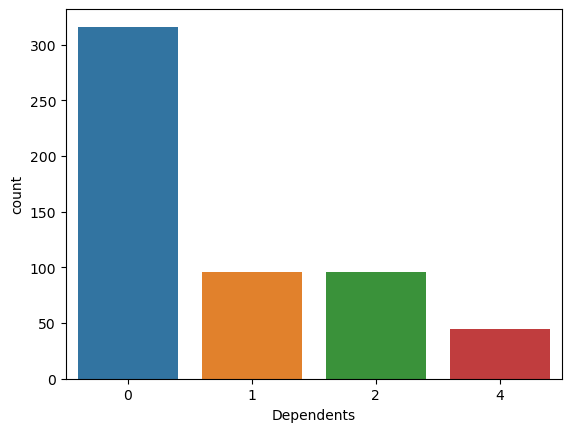

In [58]:
sns.countplot(x='Dependents',data=df)

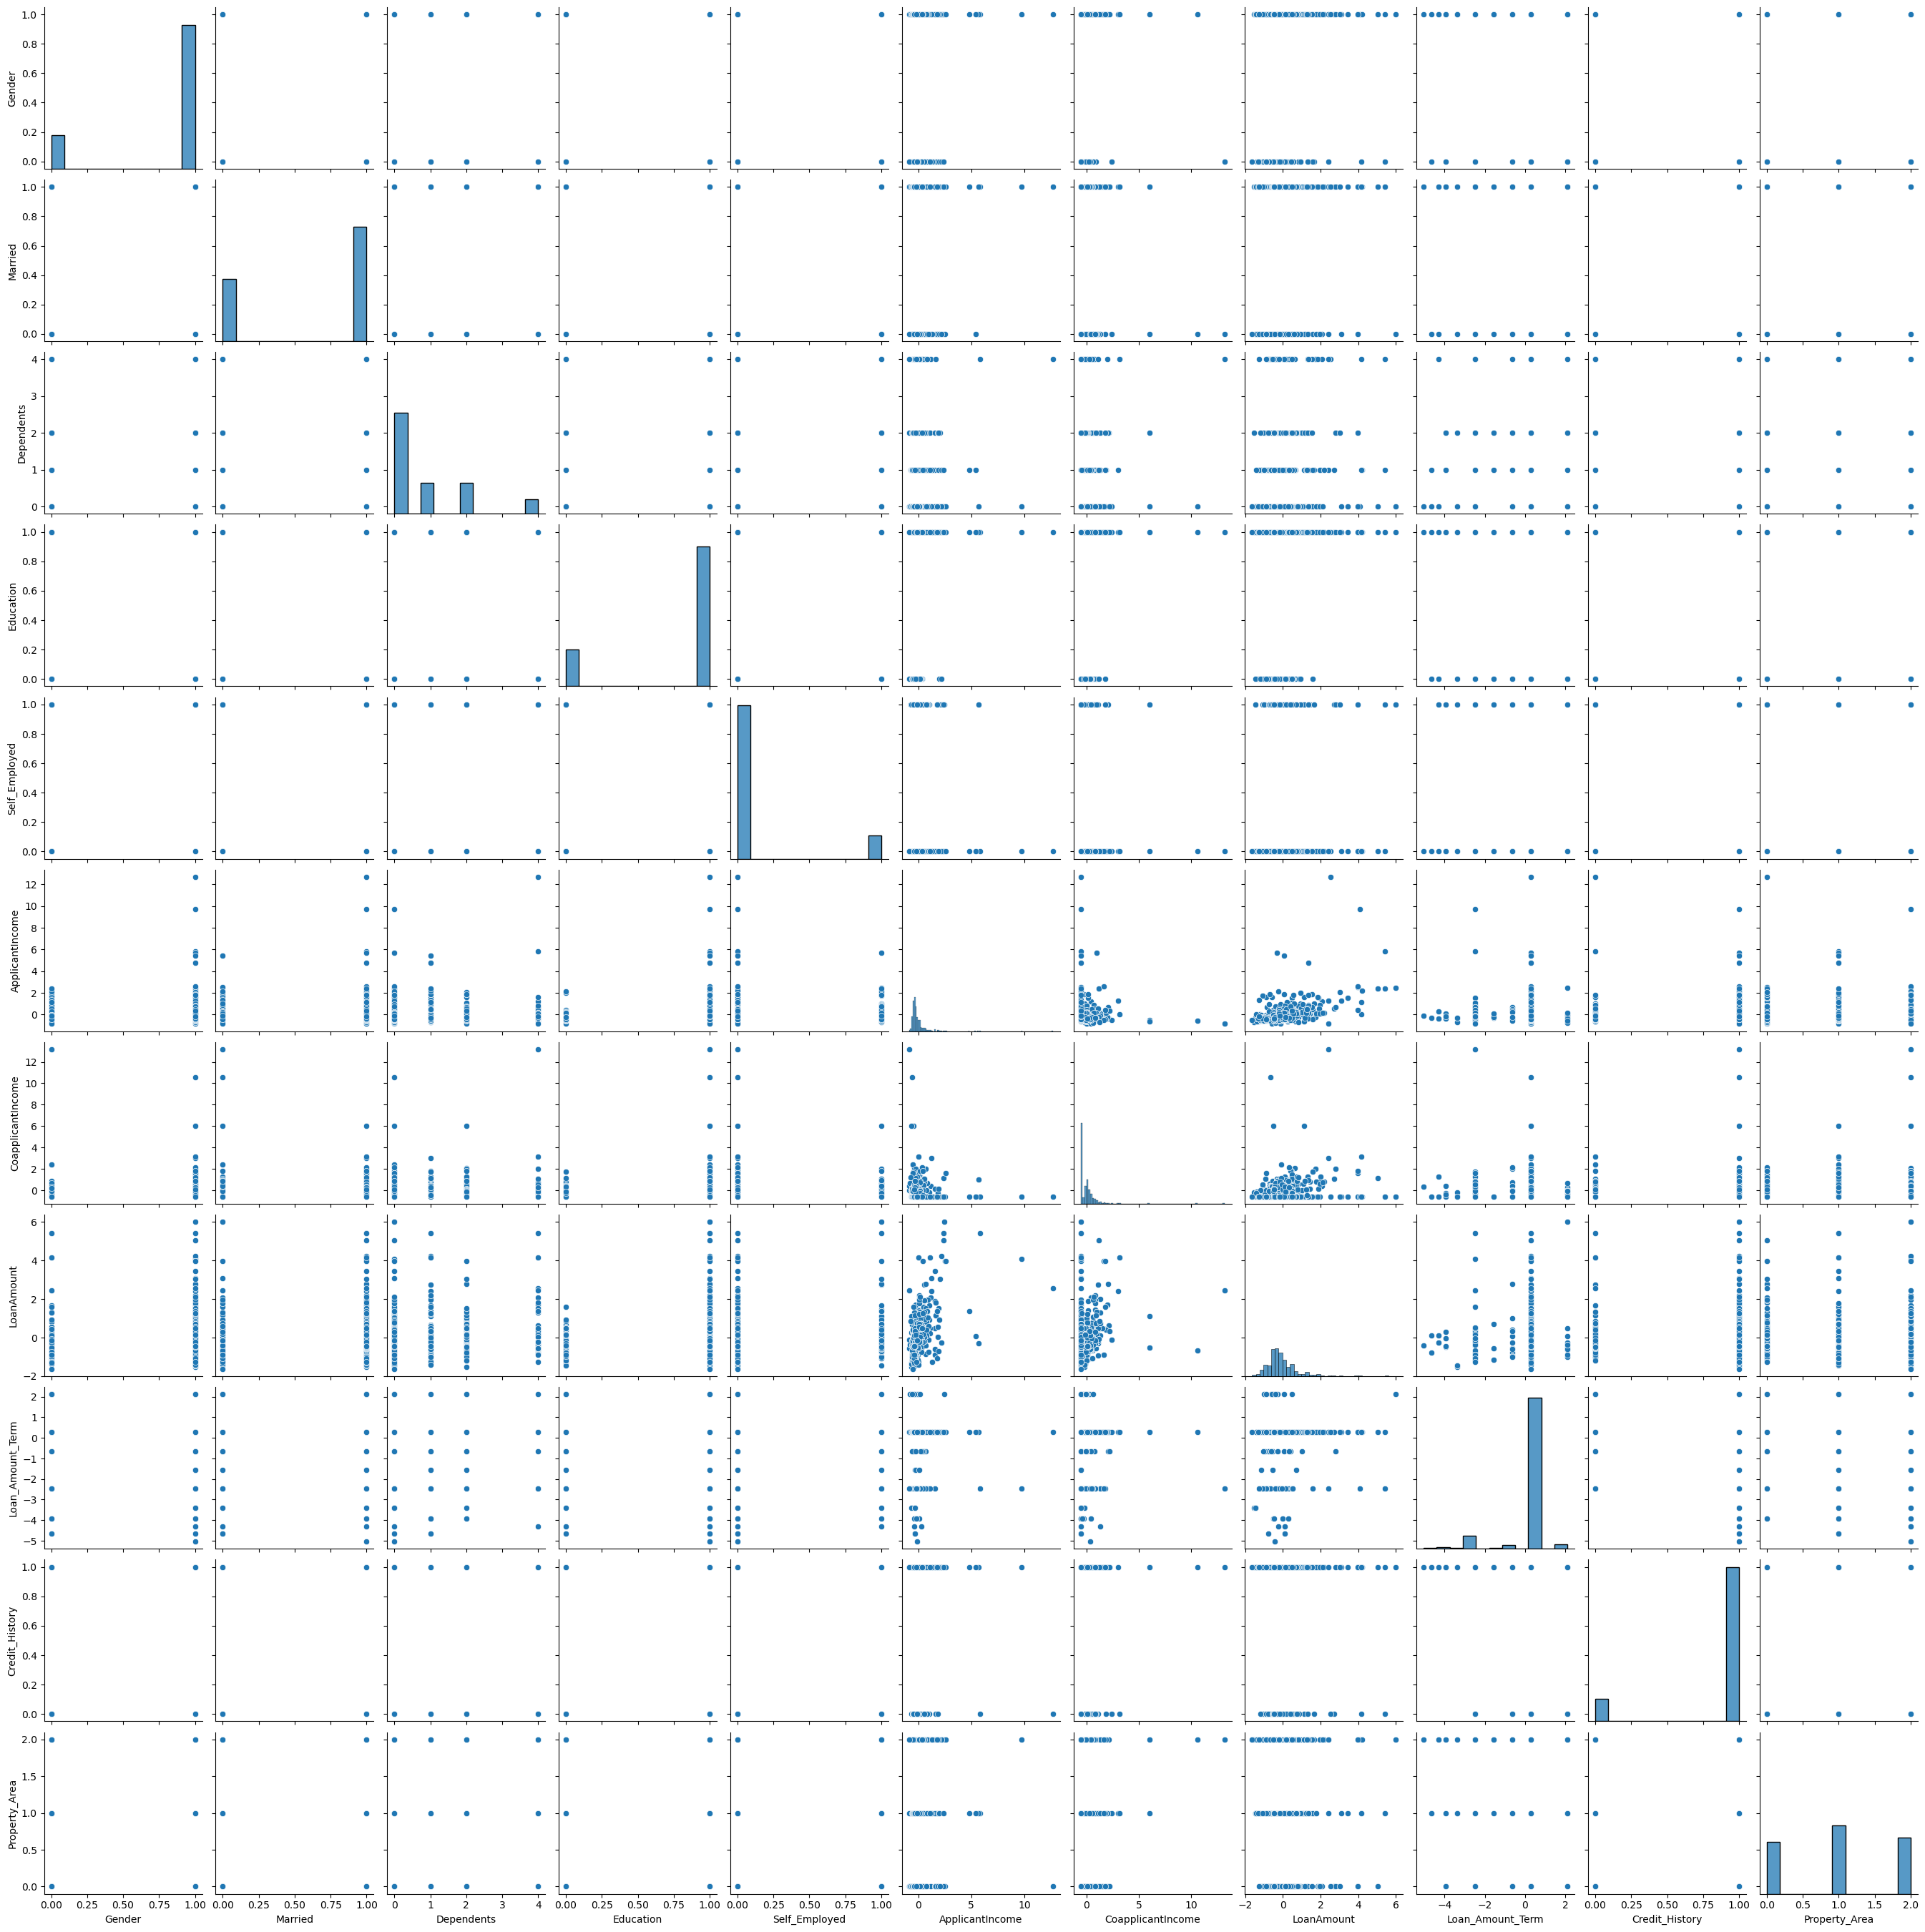

In [59]:
sns.pairplot(df)

In [60]:
pip install customtkinter


   ---------------------------------------- 0.0/296.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/296.1 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/296.1 kB 640.0 kB/s eta 0:00:01
   ---- ---------------------------------- 30.7/296.1 kB 640.0 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/296.1 kB 217.9 kB/s eta 0:00:02
   -------- ------------------------------ 61.4/296.1 kB 297.7 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB 374.1 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/296.1 kB